# AI News Event Clustering & Timeline Builder

**Dataset:** Kaggle — HuffPost News Category Dataset (`News_Category_Dataset_v3.json`)

**Pipeline overview**
1. Load and clean news articles
2. Explore the dataset (EDA)
3. Convert articles to sentence embeddings
4. Reduce dimensionality with UMAP
5. Cluster events with HDBSCAN
6. Label clusters with c-TF-IDF
7. Build timelines and extractive summaries
8. Export results for the Streamlit dashboard (`app.py`)

### Configuration
Central settings so values are not hardcoded throughout the notebook.

In [1]:
from pathlib import Path

DATA_PATH = Path('../Data/Event_Clustering/News_Category_Dataset_v3.json')
OUTPUT_CSV = Path('../Data/Event_Clustering/Processed_Events.csv')
SAMPLE_SIZE = 20_000          # most recent articles used for clustering
EMBEDDING_MODEL = 'all-MiniLM-L6-v2'
MIN_CLUSTER_SIZE = 15         # HDBSCAN: minimum articles per event
UMAP_NEIGHBORS = 15
RANDOM_STATE = 42

### Phase 1: Data Ingestion & Cleaning
Load the JSON dataset, handle missing values, remove duplicates, and combine `headline` + `short_description` into one text field for embedding.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.strip()

print('Loading dataset...')
df = pd.read_json(DATA_PATH, lines=True)

df = df.fillna('')
df = df[(df['headline'].astype(str).str.strip() != '') | (df['short_description'].astype(str).str.strip() != '')].copy()
df = df.drop_duplicates(subset=['headline'])

clean_headline = df['headline'].apply(clean_text)
clean_desc = df['short_description'].apply(clean_text)
df['text'] = (clean_headline + '. ' + clean_desc).str.strip('. ')
df['date'] = pd.to_datetime(df['date'])

print(f'Loaded {len(df):,} articles after cleaning.')

Loading dataset...
Loaded 207,996 articles after cleaning.


### Phase 2: Exploratory Data Analysis (EDA)
Understand dataset size, missing values, category distribution, and publication dates before applying ML.

In [3]:
print('--- Dataset Shape ---')
print(f'Total rows: {df.shape[0]:,}')
print(f'Columns: {list(df.columns)}')
print('\n--- Missing Values ---')
print(df.isnull().sum())
print(f"\nDate range: {df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}")

--- Dataset Shape ---
Total rows: 207,996
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date', 'text']

--- Missing Values ---
link                 0
headline             0
category             0
short_description    0
authors              0
date                 0
text                 0
dtype: int64

Date range: 2012-01-28 to 2022-09-23


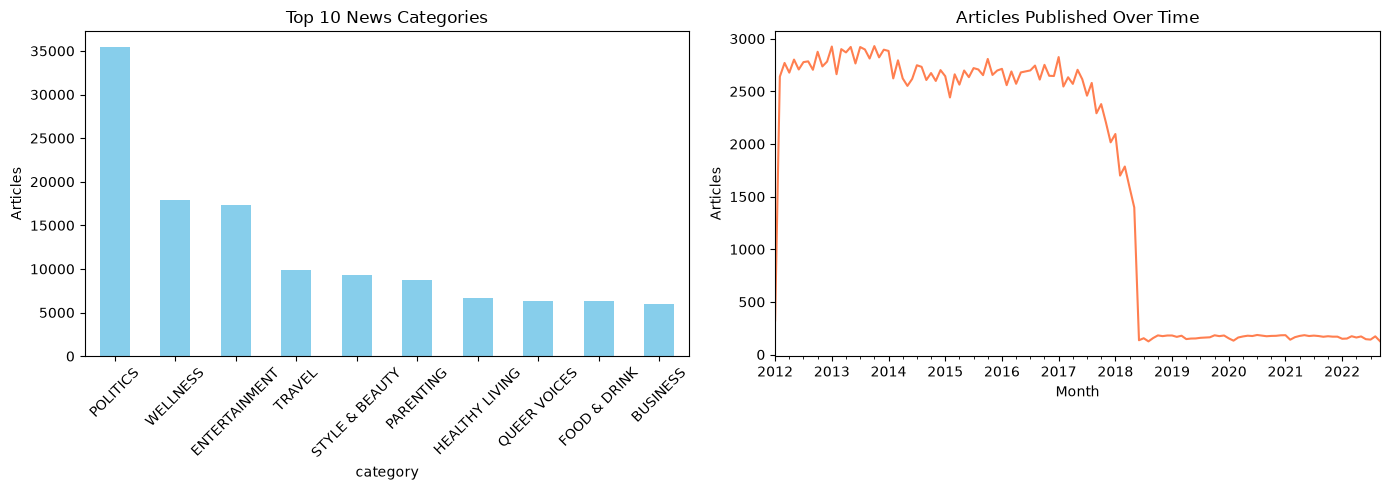

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['category'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 News Categories')
axes[0].set_ylabel('Articles')
axes[0].tick_params(axis='x', rotation=45)

df.groupby(df['date'].dt.to_period('M')).size().plot(ax=axes[1], color='coral')
axes[1].set_title('Articles Published Over Time')
axes[1].set_ylabel('Articles')
axes[1].set_xlabel('Month')

plt.tight_layout()
plt.show()

### Phase 3: Semantic Representation (Embeddings)
**Why Sentence Transformers instead of TF-IDF?**
TF-IDF treats words independently and misses semantic similarity (e.g. "market crash" vs "stock collapse"). Sentence embeddings capture meaning in dense vectors, which is better for grouping news about the same real-world event.

We sample the most recent `SAMPLE_SIZE` articles to keep runtime manageable on CPU.

In [5]:
from sentence_transformers import SentenceTransformer

df = df.sort_values('date', ascending=False).head(SAMPLE_SIZE).reset_index(drop=True)

print(f'Using {len(df):,} most recent articles for clustering.')
print('Loading SentenceTransformer...')
model = SentenceTransformer(EMBEDDING_MODEL)

print('Generating embeddings...')
embeddings = model.encode(df['text'].tolist(), show_progress_bar=True)
print(f'Embeddings shape: {embeddings.shape}')

c:\Users\raghuvaran\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using 20,000 most recent articles for clustering.
Loading SentenceTransformer...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 12851.04it/s]


Generating embeddings...


Batches: 100%|██████████| 625/625 [00:09<00:00, 63.79it/s]

Embeddings shape: (20000, 384)


### Phase 4: Dimensionality Reduction (UMAP)
Clustering in 384 dimensions is unreliable (curse of dimensionality). UMAP compresses embeddings to:
- **5D** for HDBSCAN clustering
- **2D** for visualization

Cosine metric is used because sentence embeddings are direction-based.

In [6]:
import umap.umap_ as umap

print('UMAP 5D for clustering...')
umap_5d = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, n_components=5, metric='cosine', random_state=RANDOM_STATE)
embeddings_5d = umap_5d.fit_transform(embeddings)

print('UMAP 2D for visualization...')
umap_2d = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, n_components=2, metric='cosine', random_state=RANDOM_STATE)
embeddings_2d = umap_2d.fit_transform(embeddings)

print(f'Clustering shape: {embeddings_5d.shape}')

UMAP 5D for clustering...


c:\Users\raghuvaran\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP 2D for visualization...


c:\Users\raghuvaran\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Clustering shape: (20000, 5)


### Phase 5: Event Clustering (HDBSCAN)
**Why HDBSCAN over KMeans?**
- No need to guess the number of clusters upfront
- Handles clusters of different sizes and densities
- Labels unrelated articles as noise (`-1`) instead of forcing them into a cluster

In [7]:
import hdbscan

print('Clustering with HDBSCAN...')
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    metric='euclidean',
    cluster_selection_method='eom',
)
labels = clusterer.fit_predict(embeddings_5d)
df['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int((labels == -1).sum())

print(f'Discovered {n_clusters} events.')
print(f'Flagged {n_noise:,} articles as noise ({n_noise / len(df):.1%}).')

Clustering with HDBSCAN...
Discovered 181 events.
Flagged 9,766 articles as noise (48.8%).


### Phase 6: Event Visualizations
2D UMAP scatter plot colored by cluster. Gray points are noise articles.

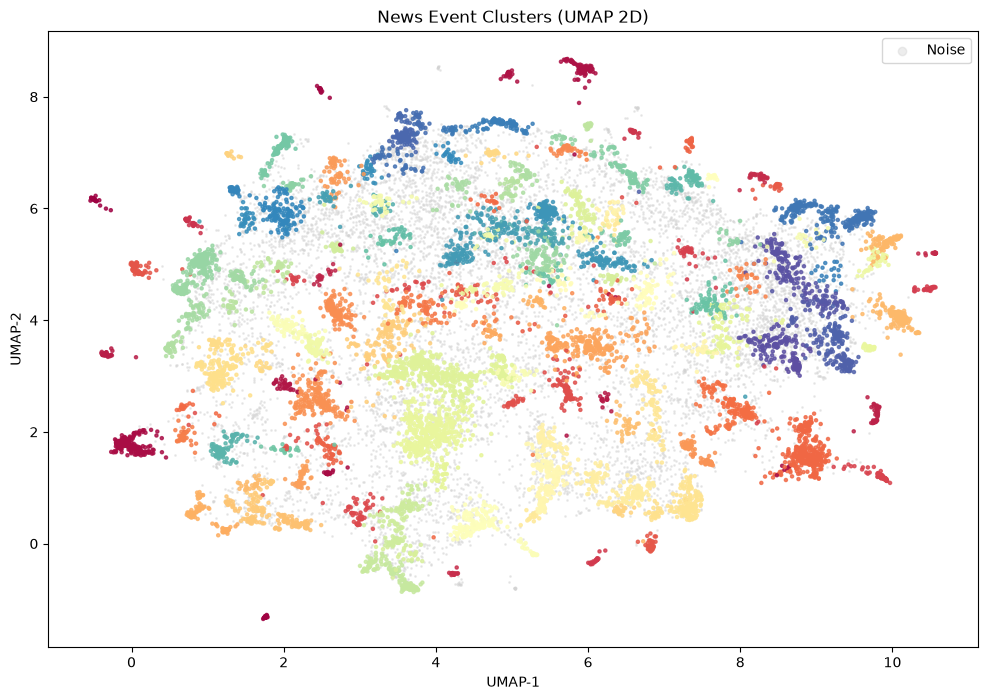

In [8]:
plt.figure(figsize=(12, 8))
noise_mask = labels == -1
clustered_mask = ~noise_mask

plt.scatter(embeddings_2d[noise_mask, 0], embeddings_2d[noise_mask, 1], c='lightgray', s=1, alpha=0.4, label='Noise')
plt.scatter(embeddings_2d[clustered_mask, 0], embeddings_2d[clustered_mask, 1], c=labels[clustered_mask], cmap='Spectral', s=5, alpha=0.8)
plt.title('News Event Clusters (UMAP 2D)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')
plt.legend(markerscale=6)
plt.show()

### Phase 7: Event Labeling (c-TF-IDF)
Each cluster is merged into one document. **Class-based TF-IDF** scores words that are frequent inside a cluster but rare across other clusters — producing meaningful event titles.

In [9]:
from pipeline_utils import extract_event_labels_ctfidf

valid_df = df[df['cluster'] != -1].copy()
docs_per_class = valid_df.groupby('cluster', as_index=False).agg({'text': ' '.join})

print('Extracting c-TF-IDF event labels...')
cluster_titles = extract_event_labels_ctfidf(docs_per_class)
valid_df['event_name'] = valid_df['cluster'].map(cluster_titles)

print('Sample discovered events:')
for cluster_id in list(cluster_titles.keys())[:5]:
    print(f'  Event {cluster_id}: {cluster_titles[cluster_id]}')

Extracting c-TF-IDF event labels...
Sample discovered events:
  Event 0: Net | Neutrality | Fcc
  Event 1: Hong | Kong | Protesters
  Event 2: Cia | Haspel | Gina
  Event 3: Mugabe | Zimbabwe | Zuma
  Event 4: Korea | North | Jong


### Phase 8: Event Timelines (Top 3 Events)
For each major event, sort articles by date and show how coverage evolved. The project requires timeline visualization for at least 3 events.

In [10]:
from pipeline_utils import print_event_timeline, top_cluster_ids

major_events = top_cluster_ids(valid_df, n=3)
for cluster_id in major_events:
    event_df = valid_df[valid_df['cluster'] == cluster_id]
    print_event_timeline(event_df, event_df['event_name'].iloc[0], limit=8)
    print()

--- CHRONOLOGICAL TIMELINE: Police | Shooting | Man (397 articles) ---

[2017-11-20] White Ex-Cop Sentenced To 15 Years For Shooting Death Of Daughter's Black Boyfriend
[2017-11-20] Ohio Man Threatened Historical Mass Shooting At Las Vegas Casino
[2017-11-23] Suspected MS-13 Gang Member Arrested In Park Stabbing, Dismembering: Cops
[2017-11-23] Baltimore Detective Killed A Day Before Testifying In Federal Case Against Fellow Cops
[2017-11-24] Central London Panics Over Reports Of Shots Fired
[2017-11-29] Suspect Is Killed After Shots Fired In Reno, Nevada
[2017-11-29] Tampa Police Arrest Suspect Amid Serial Killer Fears
[2017-12-02] Video Shows Man Who Sexually Assaulted 4-Year-Old Get Attacked By Inmate
... (389 more articles)

--- CHRONOLOGICAL TIMELINE: Olympics | Olympic | Winter (354 articles) ---

[2017-11-25] The Warwick Rowers' Steamy 2018 Calendar Has An Incredible Aim
[2017-11-28] Mikayla Holmgren Blazes Trail As First State Miss USA Contestant With Down Syndrome
[2017-12-05]

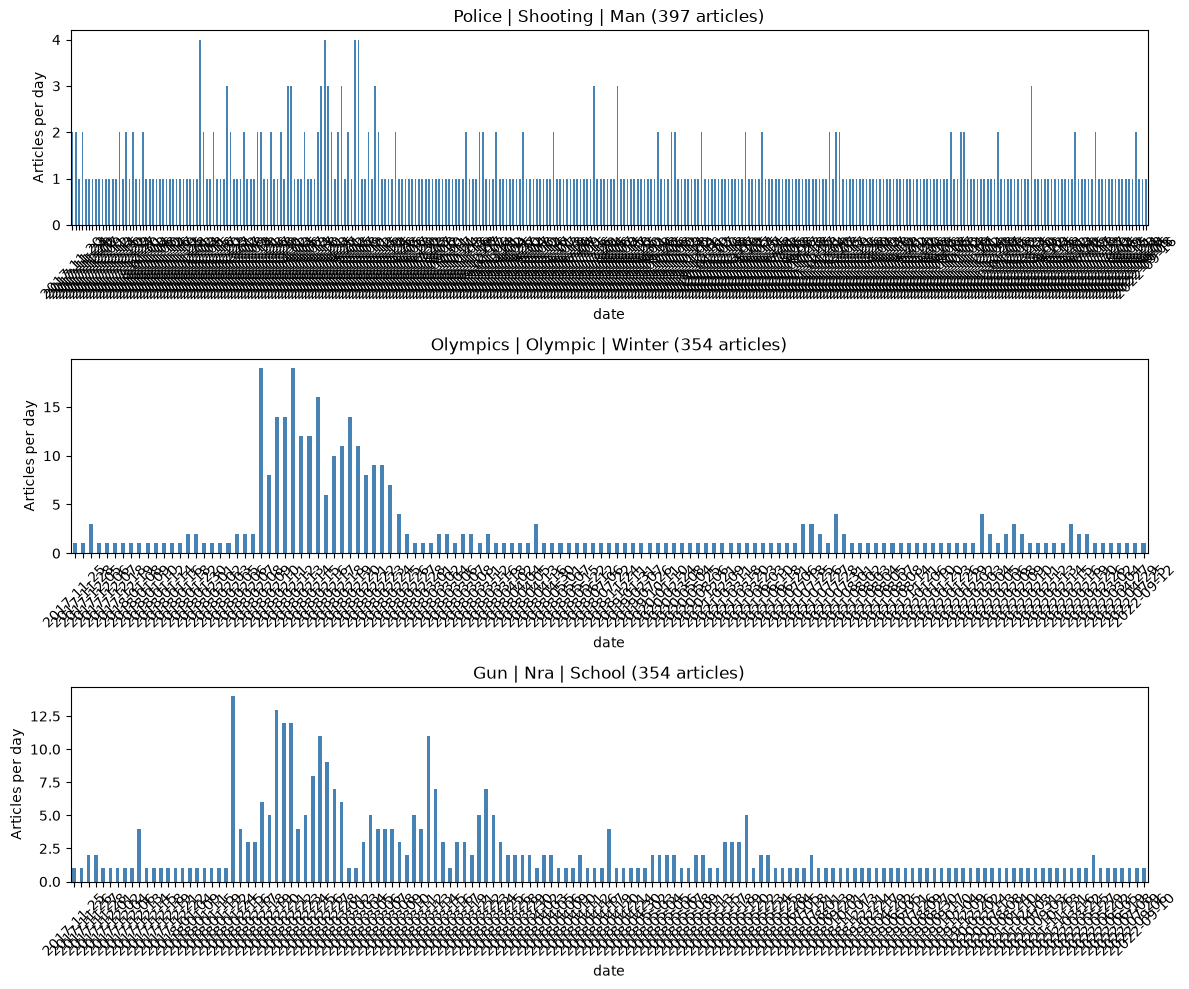

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)

for ax, cluster_id in zip(axes, major_events):
    event_df = valid_df[valid_df['cluster'] == cluster_id]
    daily = event_df.groupby(event_df['date'].dt.date).size()
    daily.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f"{event_df['event_name'].iloc[0]} ({len(event_df)} articles)")
    ax.set_ylabel('Articles per day')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Phase 9: Event Summary Generation
Extractive summaries built from the earliest and latest headlines in each event cluster.

In [12]:
from pipeline_utils import build_event_summaries, generate_event_summary

event_summaries = build_event_summaries(valid_df)
valid_df['event_summary'] = valid_df['cluster'].map(event_summaries)

print('Sample event summaries:\n')
for cluster_id in major_events:
    print(generate_event_summary(valid_df[valid_df['cluster'] == cluster_id], cluster_titles[cluster_id]))
    print()

Sample event summaries:

This event (Police | Shooting | Man) spans November 20, 2017 to September 16, 2022 with 397 articles. Early coverage focused on: White Ex-Cop Sentenced To 15 Years For Shooting Death Of Daughter's Black Boyfriend; Ohio Man Threatened Historical Mass Shooting At Las Vegas Casino. Recent developments include: Politician's DNA Connected To Las Vegas Journalist’s Murder, Police Say; Alabama Sidesteps Compensation For Survivor Of '63 KKK Blast.

This event (Olympics | Olympic | Winter) spans November 25, 2017 to September 12, 2022 with 354 articles. Early coverage focused on: The Warwick Rowers' Steamy 2018 Calendar Has An Incredible Aim; Mikayla Holmgren Blazes Trail As First State Miss USA Contestant With Down Syndrome. Recent developments include: Armand Duplantis Breaks Pole Vault World Record, Reignites Comparison To Timothee Chalamet; Boston Marathon To Make Race More Inclusive For Nonbinary Runners.

This event (Gun | Nra | School) spans November 25, 2017 to 

### Phase 10: Export & Streamlit Dashboard
Save clustered events to CSV, then launch the interactive UI:

```bash
py -3 -m streamlit run app.py
```

In [13]:
export_df = valid_df[
    ['date', 'headline', 'short_description', 'cluster', 'event_name', 'event_summary']
].sort_values(['cluster', 'date'])

export_df.to_csv(OUTPUT_CSV, index=False)
print(f'Exported {len(export_df):,} articles across {export_df["cluster"].nunique()} events to {OUTPUT_CSV}.')
print('Run: py -3 -m streamlit run app.py')

Exported 10,234 articles across 181 events to Processed_Events.csv.
Run: py -3 -m streamlit run app.py
